## Exercise 0 - Iris flower dataset (*)

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

### a, Check keys on iris loaded data to explore

In [4]:
iris = load_iris()
# data = load_iris()
# data

# alternative method w/o pandas
# iris = load_iris(as_frame=True)
# df = iris.frame.copy()

df = pd.DataFrame(iris.data, columns= iris.feature_names)
df = pd.concat([df, pd.DataFrame(iris.target, columns= ["iris_species"])], axis = 1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
df.shape

(150, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   iris_species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [60]:
# to see metadata and read about the dataset
# print(iris["DESCR"])

In [8]:
len(iris["feature_names"])

4

In [9]:
# 150 samples, 4 features 
iris["target"].shape, iris["data"].shape

((150,), (150, 4))

In [10]:
iris["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [12]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
df_target = pd.DataFrame(iris["target"], columns=["class"])
df_target.head()

,class
0,0
1,0
2,0
3,0
4,0


In [15]:
#concatenate
"hej" + "svej"

'hejsvej'

In [16]:
df_iris = pd.concat([df, df_target], axis="columns")
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### b, After initial exploration of dataset, insert into DF
### c, Do EDA
### d, Make correlation heat map. Explore numbers

In [17]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [18]:
# when testing algorithm -> get a sense of the ranges usable
# when validating input data (utilise matrix below for this)
df_iris.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
class,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


#### insights:
for class 0
- in general shorter sepal length
- longest sepal width
- petal length and petal width shortest

for class 1 ...

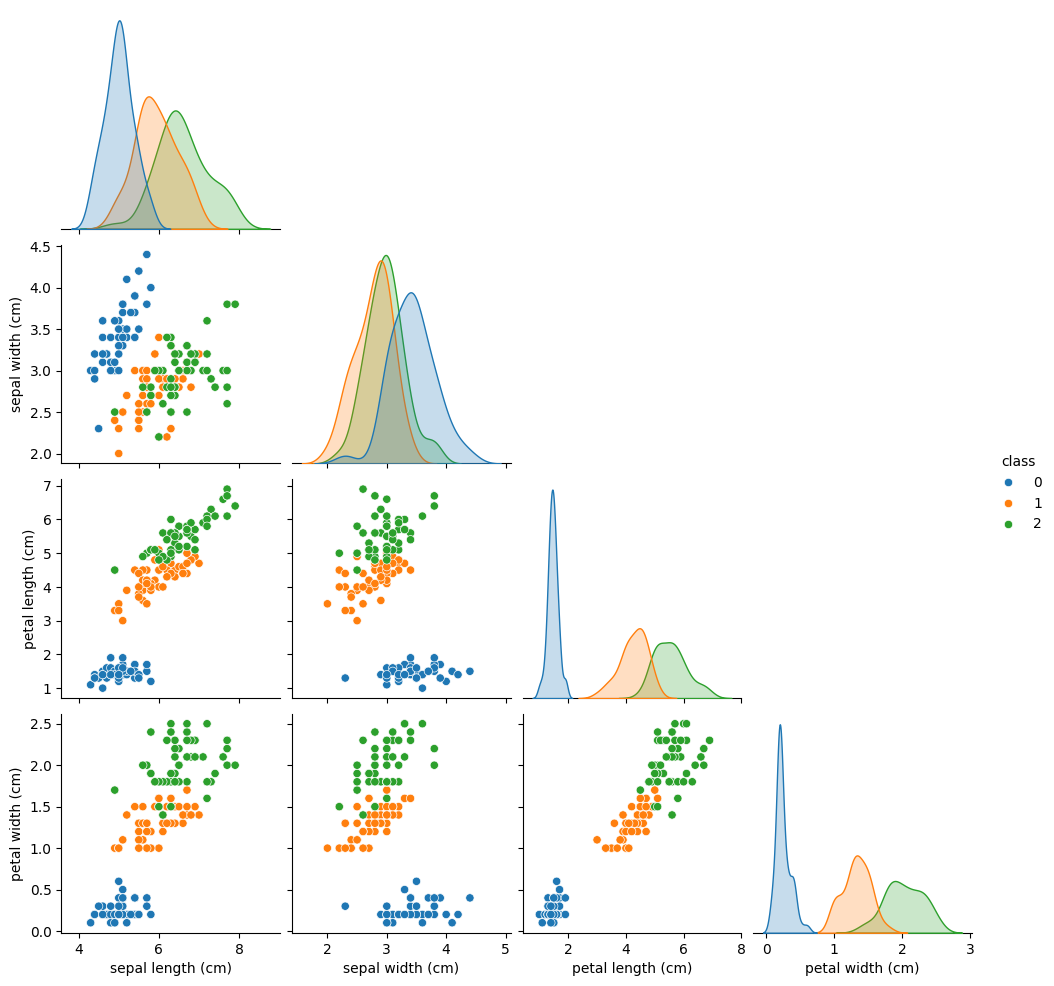

In [19]:
sns.pairplot(df_iris, corner=True, hue="class", palette="tab10") # alternative palette="colorblind"
# note - if many features, pairplots are not suitable. in such cases select a few features

In [20]:
df["target"] = iris.target

In [21]:
# rename the numerical targets in legend
species_names = {0:"Setosa", 1:"Versicolor", 2:"Virginica"}
df["iris_species"] = df["target"].map(species_names)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

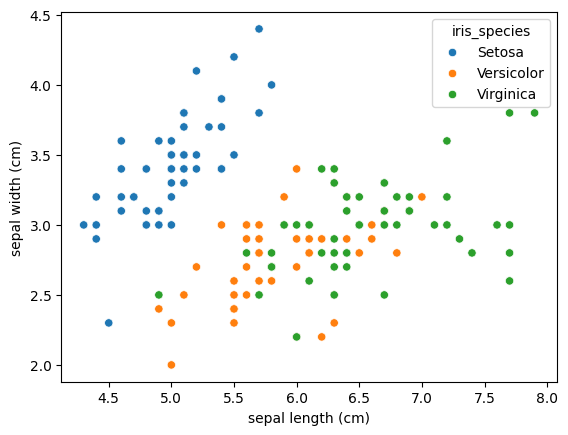

In [22]:
# heat map / scatter plot of how the features relate
sns.scatterplot(data=df, x= "sepal length (cm)", y= "sepal width (cm)", hue= "iris_species")

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

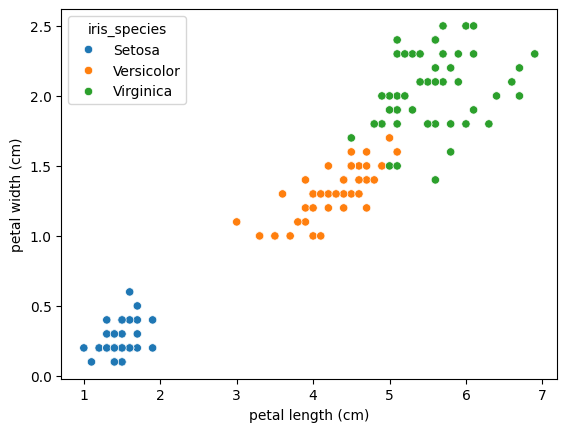

In [23]:
sns.scatterplot(data=df, x= "petal length (cm)", y= "petal width (cm)", hue= "iris_species")

### d, Correlation Heatmap

In [24]:
df_iris.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
class,0.782561,-0.426658,0.949035,0.956547,1.000000


<Axes: >

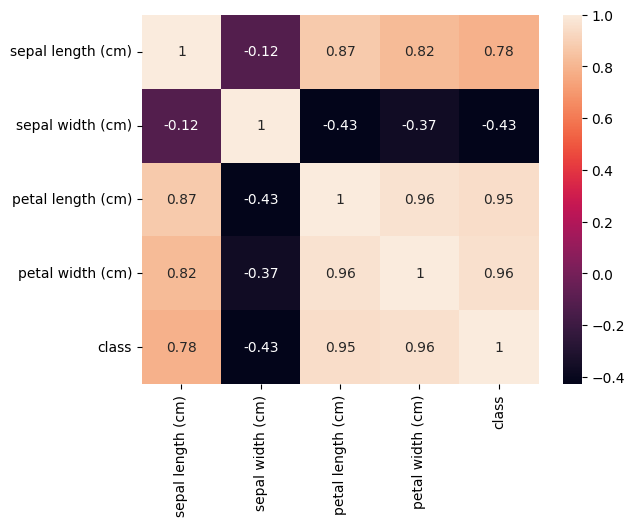

In [25]:
sns.heatmap(df_iris.corr(), annot=True)

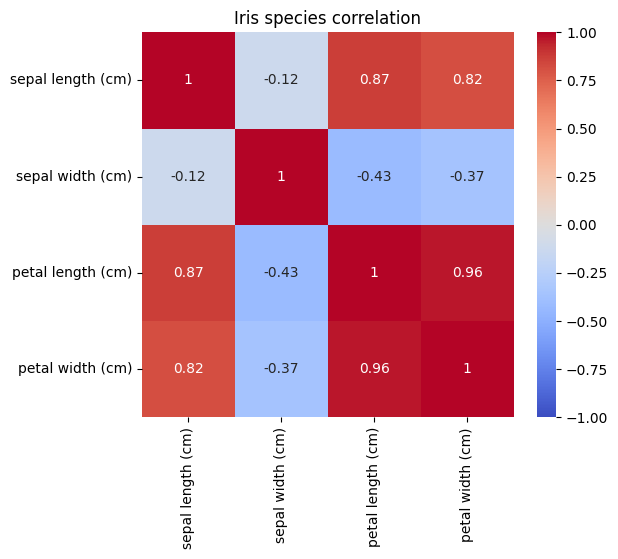

In [26]:
import matplotlib.pyplot as plt
import numpy as np

feature_columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
corr = df[feature_columns].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, vmin= -1, vmax= 1, center=0, cmap="coolwarm")
plt.title("Iris species correlation")
plt.show()

#### e, Create boxplot

<Axes: >

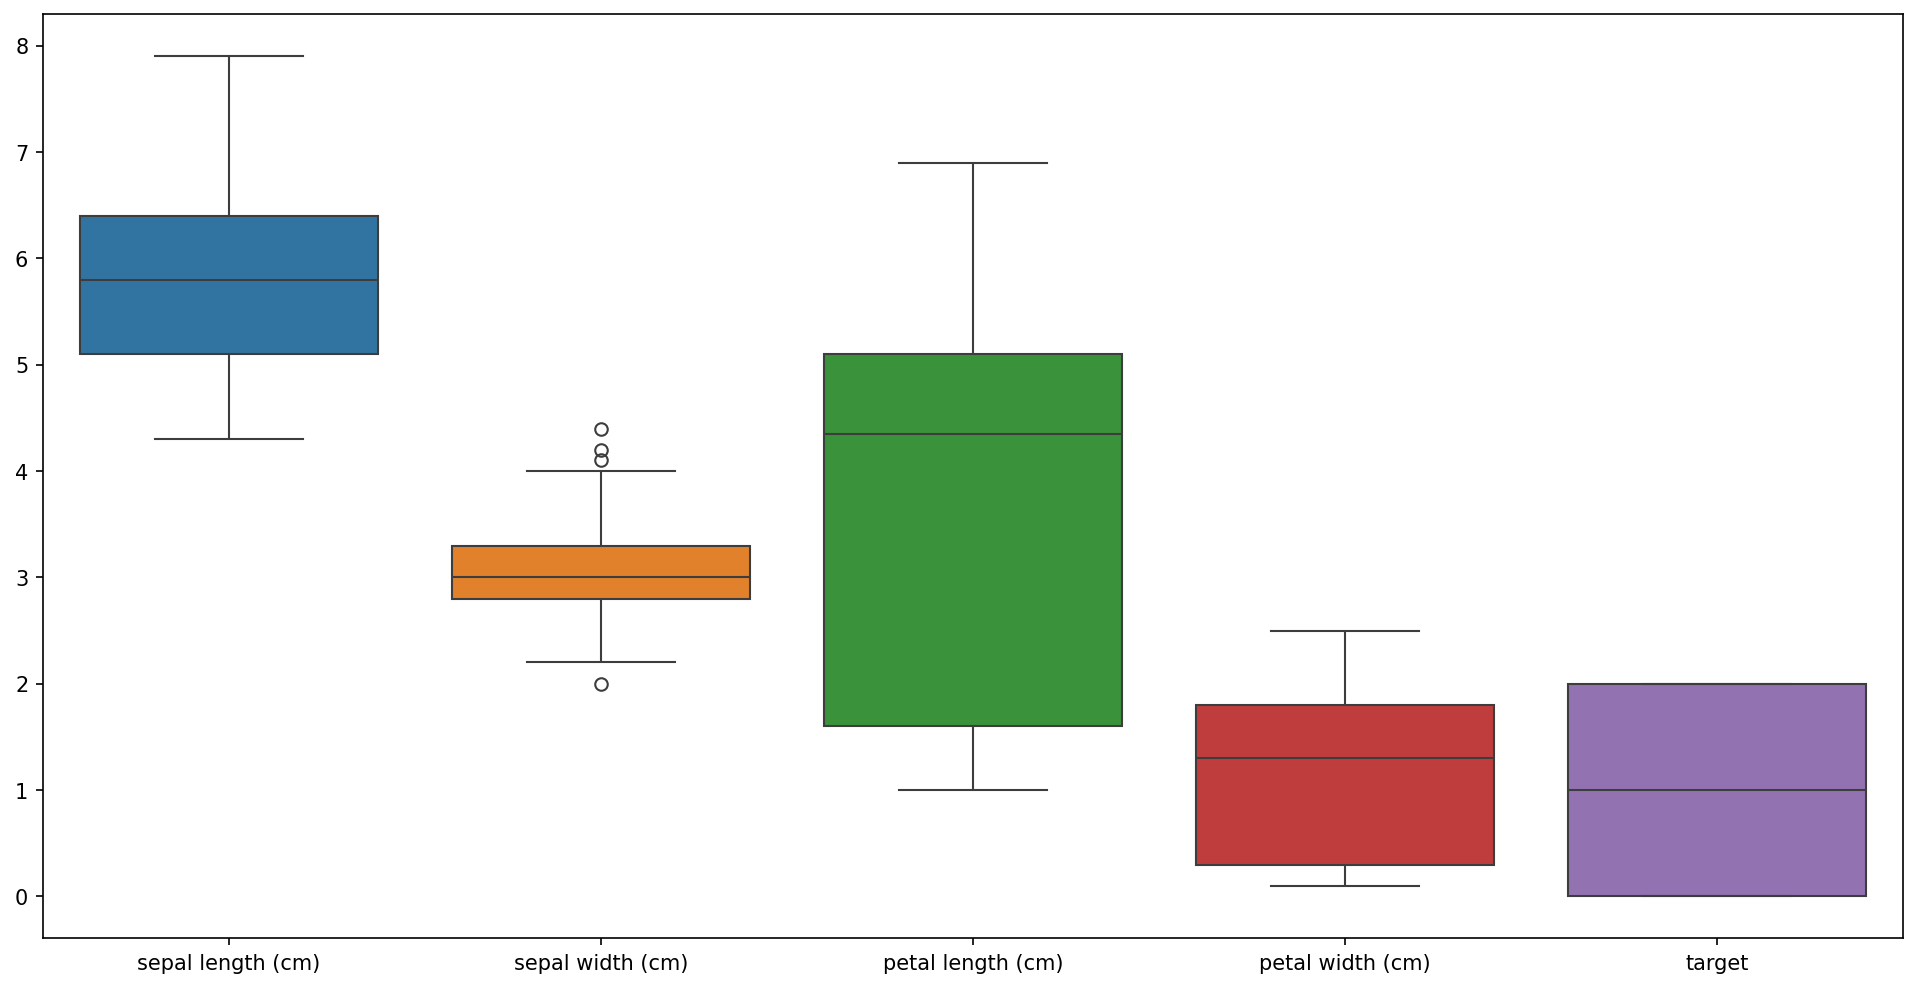

In [27]:
fig, ax = plt.subplots(1, figsize= (16, 8), dpi=150)
sns.boxplot(df)

# max/min and outliers


<Axes: xlabel='iris_species', ylabel='sepal width (cm)'>

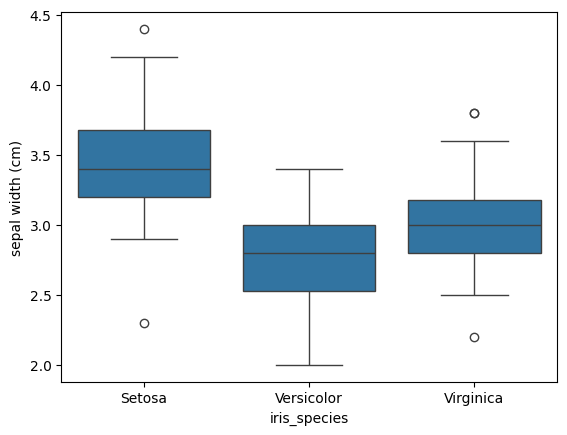

In [28]:
sns.boxplot(data=df, x="iris_species", y="sepal width (cm)", gap=0) #(hue="Species")

### f, Remove outliers in data from boxplot using Tukey's rule 
### lower bound outlier Q1 - 1.5 x IQR
### upper bound outlier Q3 + 1.5 x IQR
### IQR = Q3 - Q1

In [29]:
q1 = df_iris["sepal width (cm)"].quantile(.25)
q1

np.float64(2.8)

In [30]:
q3 = df_iris["sepal width (cm)"].quantile(.75)
q3

np.float64(3.3)

In [31]:
iqr = q3-q1
iqr

np.float64(0.5)

In [32]:
lower_bound = q1-1.5*iqr
higher_bound = q3+1.5*iqr

lower_bound, higher_bound

(np.float64(2.05), np.float64(4.05))

In [33]:
# add boolean mask
(df_iris["sepal width (cm)"] > lower_bound).sum()

np.int64(149)

In [34]:
(df_iris["sepal width (cm)"] < higher_bound).sum()

np.int64(147)

In [35]:
df_no_outliers = df_iris[
    (df_iris["sepal width (cm)"] > lower_bound)
    & (df_iris["sepal width (cm)"] < higher_bound)
]
df_no_outliers.shape

(146, 5)

In [36]:
X, y = df_no_outliers.drop("class", axis=1),df_no_outliers["class"]

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((97, 4), (49, 4))

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.mean(), scaled_X_train.std(), scaled_X_test.mean(), scaled_X_test.std()

(np.float64(2.998746726307124e-16),
 np.float64(0.9999999999999998),
 np.float64(-0.026200181679167715),
 np.float64(0.9999349444958894))

### i, classify the first 10 values of X_test and compare manually

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(scaled_X_train, y_train)

model.predict(scaled_X_test)[:10]

array([0, 2, 0, 0, 0, 2, 0, 1, 2, 0])

In [40]:
y_test.iloc[:10].values

array([0, 2, 0, 0, 0, 2, 0, 1, 1, 0])

### j, Evaluate

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.91      0.95        11
           2       0.95      1.00      0.97        19

    accuracy                           0.98        49
   macro avg       0.98      0.97      0.98        49
weighted avg       0.98      0.98      0.98        49



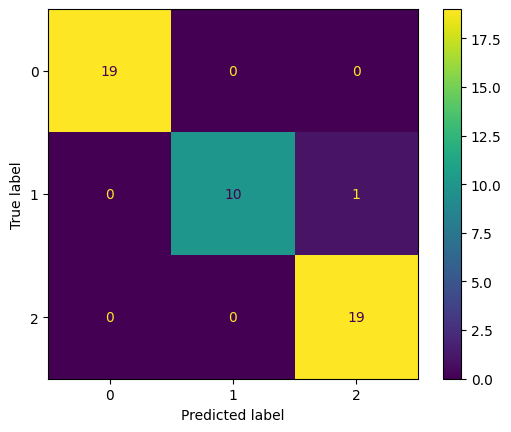

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(scaled_X_test)
print(classification_report(y_test, y_pred))

cm= confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [52]:
# compute IQR InterQuartile Range for lower and upper outliers of the dataset
# using Tukey's rule for boxplot 

Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - (1.5*IQR)
upper = Q3 + (1.5*IQR)

print(lower)
print(upper)

sepal length (cm)    3.15
sepal width (cm)     2.05
petal length (cm)   -3.65
petal width (cm)    -1.95
dtype: float64
sepal length (cm)     8.35
sepal width (cm)      4.05
petal length (cm)    10.35
petal width (cm)      4.05
dtype: float64


In [57]:
# keep only rows inside bounds:
inside_bounds = ((df[feature_columns] >= lower) & (df[feature_columns] <= upper))
row_mask = inside_bounds.all(axis=1)
df_clean = df.loc[row_mask]
df_clean.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species,target
0,5.1,3.5,1.4,0.2,Setosa,0
1,4.9,3.0,1.4,0.2,Setosa,0
2,4.7,3.2,1.3,0.2,Setosa,0
3,4.6,3.1,1.5,0.2,Setosa,0
4,5.0,3.6,1.4,0.2,Setosa,0


### g, Do train|test split and scale using feature standardization

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X, y = df_clean[feature_columns], df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

# feature standardization
scaler = MinMaxScaler

# Normalise data:
# scale from training data and apply
scaled_X_train = scaler.fit_transform(X_train)
# scale test data and apply 
scaled_X_test = scaler.transform(X_test)

# Use KNN to classify iris data set

### divide into feature matrix and target vector

In [44]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [56]:
df_no_outliers.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [59]:
X, y = df_no_outliers.drop("class", axis=1), df_no_outliers["class"]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Train|test split

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.5, random_state=42)

X_train.shape

(73, 4)

### Scale data set

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.min(), scaled_X_train.max(), scaled_X_test.min(), scaled_X_test.max()

(np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0350877192982457))

### KNN Model

In [62]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1) # n_neighbors hyperparameter k
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)
y_pred

array([0, 2, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 2, 0, 1, 1, 0, 1, 1, 2, 1, 2,
       2, 0, 1, 1, 1, 2, 1])

In [63]:
y_test.values

array([0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 2, 0, 1, 1, 0, 1, 1, 2, 1, 2,
       2, 0, 1, 1, 1, 1, 1])

### Evaluate

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.95      0.91      0.93        23
           2       0.92      0.96      0.94        23

    accuracy                           0.96        73
   macro avg       0.96      0.96      0.96        73
weighted avg       0.96      0.96      0.96        73



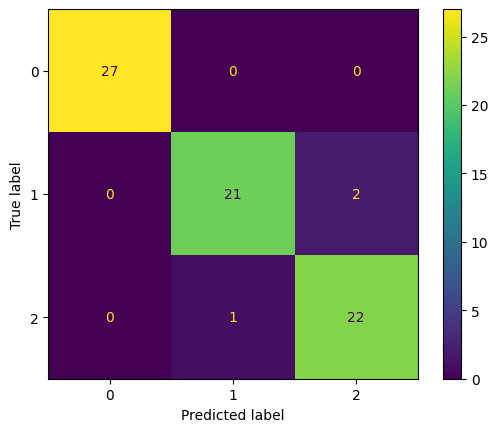

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

### Tune hyperparameter K(n_neighbour) with elbow plot

In [67]:
df_no_outliers["class"].value_counts()  #almost even spread

class
2    50
1    49
0    47
Name: count, dtype: int64

In [68]:
from sklearn.metrics import accuracy_score

error = 1-accuracy_score(y_test, y_pred)
error

0.04109589041095896

### Plot graph of errors of y and k in x

In [69]:
error_list = []
for k in range(1,50):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)
    error = 1 - accuracy_score(y_test, y_pred)
    error_list.append(error)

error_list

[0.04109589041095896,
 0.0547945205479452,
 0.0547945205479452,
 0.0273972602739726,
 0.0547945205479452,
 0.04109589041095896,
 0.04109589041095896,
 0.0273972602739726,
 0.0273972602739726,
 0.0273972602739726,
 0.0273972602739726,
 0.0273972602739726,
 0.04109589041095896,
 0.0547945205479452,
 0.0273972602739726,
 0.0273972602739726,
 0.0273972602739726,
 0.0547945205479452,
 0.04109589041095896,
 0.0273972602739726,
 0.04109589041095896,
 0.0547945205479452,
 0.0547945205479452,
 0.06849315068493156,
 0.0821917808219178,
 0.0821917808219178,
 0.06849315068493156,
 0.12328767123287676,
 0.1095890410958904,
 0.1095890410958904,
 0.12328767123287676,
 0.15068493150684936,
 0.15068493150684936,
 0.136986301369863,
 0.136986301369863,
 0.136986301369863,
 0.15068493150684936,
 0.15068493150684936,
 0.136986301369863,
 0.136986301369863,
 0.4383561643835616,
 0.5068493150684932,
 0.5068493150684932,
 0.5068493150684932,
 0.4657534246575342,
 0.5205479452054795,
 0.4931506849315068,
 0.5

[Text(0.5, 0, 'k neighbour'),
 Text(0, 0.5, 'Error'),
 Text(0.5, 1.0, 'Elbow plot to choose k')]

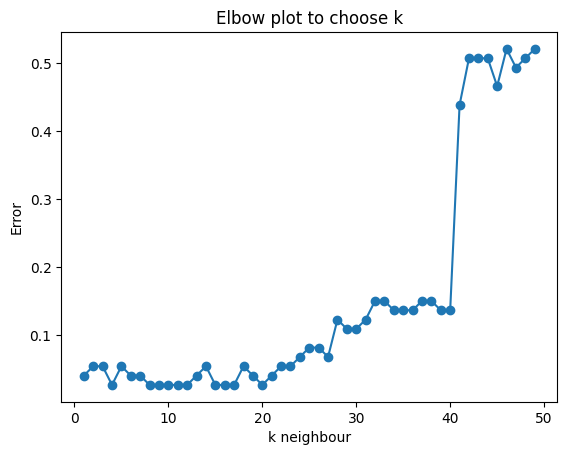

In [70]:
fig, ax = plt.subplots(1)
ax.plot(range(1, 50), error_list, '-o')

ax.set(xlabel= "k neighbour", ylabel= "Error", title="Elbow plot to choose k")

### Choose k = 41 or 42 ??
- too high?